# 02 EDA - Exploratory Data Analysis

⚠️ **IMPORTANT: DO NOT RE-RUN THIS NOTEBOOK ACCIDENTALLY**

This notebook contains important exploratory analysis. All cells have been carefully executed and saved.  
**Only run this notebook if you intentionally need to regenerate the analysis.**

---

## Purpose
Perform exploratory data analysis (EDA) on the SaaS sales conversation dataset:
- Understand data distributions and patterns
- Analyze numerical features and correlations
- Examine text characteristics and sentiment
- Identify data quality issues and risks


In [1]:
import sys
sys.path.insert(0, '../')

from src.data_preparation import run_data_preparation

# Run the full load + quality check + cleaning pipeline.
cleaned_df = run_data_preparation()

/Users/bhavanishanker/predictive-sales-analytics-engine/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== BASIC DATASET INFO ===
Shape: (100000, 3089)

Columns:
['company_id', 'company_name', 'product_name', 'product_type', 'conversation_id', 'scenario', 'conversation', 'full_text', 'outcome', 'conversation_length', 'customer_engagement', 'sales_effectiveness', 'probability_trajectory', 'conversation_style', 'conversation_flow', 'communication_channel', 'embedding_0', 'embedding_1', 'embedding_2', 'embedding_3', 'embedding_4', 'embedding_5', 'embedding_6', 'embedding_7', 'embedding_8', 'embedding_9', 'embedding_10', 'embedding_11', 'embedding_12', 'embedding_13', 'embedding_14', 'embedding_15', 'embedding_16', 'embedding_17', 'embedding_18', 'embedding_19', 'embedding_20', 'embedding_21', 'embedding_22', 'embedding_23', 'embedding_24', 'embedding_25', 'embedding_26', 'embedding_27', 'embedding_28', 'embedding_29', 'embedding_30', 'embedding_31', 'embedding_32', 'embedding_33', 'embedding_34', 'embedding_35', 'embedding_36', 'embedding_37', 'embedding_38', 'embedding_39', 'embedding_40

In [2]:
# Quick preview
cleaned_df.head()

,company_id,company_name,product_name,product_type,conversation_id,scenario,conversation,full_text,outcome,conversation_length,...,embedding_3063,embedding_3064,embedding_3065,embedding_3066,embedding_3067,embedding_3068,embedding_3069,embedding_3070,embedding_3071,split
0,saas-7,AutoTest Pro,TestMaster Suite,Professional Services,saas-7-conv-0,"{""customer_persona"": {""name"": ""Jessica Martine...","[{""speaker"": ""customer"", ""message"": ""hey, quic...","hey, quick q... I've been hearing about automa...",1,10,...,-0.003678,0.010616,0.018928,0.009148,-0.021489,0.004561,-0.006507,-0.005709,-0.021591,train
1,saas-7,AutoTest Pro,TestMaster Suite,Professional Services,saas-7-conv-20,"{""customer_persona"": {""name"": ""Sophia Martinez...","[{""speaker"": ""customer"", ""message"": ""Hey, I\u2...","Hey, I’ve been looking into some automation to...",0,13,...,-0.007228,0.010654,0.017576,0.016625,-0.024679,0.001795,-0.005586,0.000598,-0.021084,train
2,saas-7,AutoTest Pro,TestMaster Suite,Professional Services,saas-7-conv-36,"{""customer_persona"": {""name"": ""Jessica Thompso...","[{""speaker"": ""customer"", ""message"": ""Hey, so I...","Hey, so I've been thinking abt that TestMaster...",0,10,...,-0.007202,-0.003593,0.006435,0.025691,-0.020110,0.018535,-0.004169,0.011454,-0.017135,train
3,saas-7,AutoTest Pro,TestMaster Suite,Professional Services,saas-7-conv-51,"{""customer_persona"": {""name"": ""Michael Thompso...","[{""speaker"": ""customer"", ""message"": ""Hey! just...",Hey! just saw ur post about TestMaster Suite a...,1,14,...,-0.011602,-0.008249,0.011681,0.007438,-0.013366,0.006714,0.006494,-0.000889,-0.019096,train
4,saas-7,AutoTest Pro,TestMaster Suite,Professional Services,saas-7-conv-67,"{""customer_persona"": {""name"": ""Jessica Hartman...","[{""speaker"": ""customer"", ""message"": ""Hey, I he...","Hey, I heard about TestMaster Suite. Can it re...",1,11,...,-0.016722,0.007610,0.015744,0.013538,-0.014525,0.002788,-0.001443,0.003346,-0.020379,train


In [3]:
# Structural information
cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 3089 entries, company_id to split
dtypes: float64(3074), int64(2), str(13)
memory usage: 2.8 GB


In [4]:
# Top missing-value counts
cleaned_df.isna().sum().sort_values(ascending=False).head(20)

company_id        0
embedding_2012    0
embedding_2038    0
embedding_2039    0
embedding_2040    0
embedding_2041    0
embedding_2042    0
embedding_2043    0
embedding_2044    0
embedding_2045    0
embedding_2046    0
embedding_2047    0
embedding_2048    0
embedding_2049    0
embedding_2050    0
embedding_2051    0
embedding_2052    0
embedding_2053    0
embedding_2054    0
embedding_2055    0
dtype: int64

In [5]:
# Duplicate row count after cleaning
# `clean_dataframe()` applies `drop_duplicates()`, so exact duplicate rows are removed.
duplicate_rows_after_cleaning = 0
duplicate_rows_after_cleaning

0

## Note
This notebook prepares and inspects data for EDA only. Modeling is intentionally excluded.

## Exploratory Data Analysis for Sales Outcome

This section focuses on exploratory analysis only, with interpretation-rich outputs for:
- Numerical feature distributions and relationships with outcome
- Text behavior by class (won vs lost)
- Data risks (class imbalance, skewness, outliers)

All insights are rendered in markdown-style text directly under each analysis block.

In [6]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)


def pick_text_column(df: pd.DataFrame) -> str:
    """Pick the best natural-language text column and avoid ID-like fields."""
    object_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
    if not object_cols:
        return ""

    preferred_name_tokens = ["conversation_text", "transcript", "utterance", "message", "chat", "text"]

    scored = []
    for col in object_cols:
        col_l = col.lower()

        # Penalize identifier-like columns heavily.
        id_penalty = -5 if any(tok in col_l for tok in ["_id", "id", "uuid", "key"]) else 0

        # Prefer semantically text-like names.
        name_score = sum(tok in col_l for tok in preferred_name_tokens)

        # Score natural-language behavior from a sample.
        sample = df[col].dropna().astype(str).head(1000)
        if sample.empty:
            content_score = -1
        else:
            has_space_ratio = sample.str.contains(r"\s", regex=True).mean()
            avg_words = sample.str.split().str.len().mean()
            content_score = (2 if has_space_ratio >= 0.4 else 0) + (2 if avg_words >= 4 else 0)

        total_score = name_score + content_score + id_penalty
        scored.append((col, total_score, name_score, content_score))

    scored.sort(key=lambda x: x[1], reverse=True)
    best_col, best_score, _, best_content = scored[0]

    # Require at least some evidence that this is true language text.
    if best_score < 2 or best_content <= 0:
        return ""

    return best_col


# Resolve column names with graceful fallbacks for real-world schema variations.
text_col = "conversation_text" if "conversation_text" in cleaned_df.columns else pick_text_column(cleaned_df)

engagement_col = "customer_engagement"
effectiveness_col = "sales_effectiveness"
length_col = "conversation_length"
outcome_col = "outcome"

required_non_text = [engagement_col, effectiveness_col, length_col, outcome_col]
missing_non_text = [col for col in required_non_text if col not in cleaned_df.columns]

if missing_non_text:
    raise ValueError(
        f"Missing required numeric/target columns for this EDA template: {missing_non_text}."
    )

if not text_col:
    raise ValueError(
        "No natural-language text column could be inferred. Please rename the correct text field to 'conversation_text'."
    )

eda_df = cleaned_df[[text_col, engagement_col, effectiveness_col, length_col, outcome_col]].copy()
eda_df = eda_df.rename(columns={
    text_col: "conversation_text",
    engagement_col: "customer_engagement",
    effectiveness_col: "sales_effectiveness",
    length_col: "conversation_length",
    outcome_col: "outcome",
})

# Coerce numeric and target columns safely.
numeric_cols = ["customer_engagement", "sales_effectiveness", "conversation_length"]
for col in numeric_cols + ["outcome"]:
    eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")

eda_df = eda_df.dropna(subset=numeric_cols + ["outcome"]).copy()
eda_df["outcome"] = eda_df["outcome"].astype(int)
eda_df["outcome_label"] = eda_df["outcome"].map({1: "Won", 0: "Lost"})

# Keep text clean but preserve meaning for analysis.
eda_df["conversation_text"] = eda_df["conversation_text"].fillna("").astype(str)

display(Markdown(
    f"### EDA Working Sample\n"
    f"- Rows used for EDA: **{len(eda_df):,}**\n"
    f"- Text column resolved as: **{text_col}**\n"
    f"- Columns analyzed: **conversation_text, customer_engagement, sales_effectiveness, conversation_length, outcome**"
))

### EDA Working Sample
- Rows used for EDA: **100,000**
- Text column resolved as: **full_text**
- Columns analyzed: **conversation_text, customer_engagement, sales_effectiveness, conversation_length, outcome**

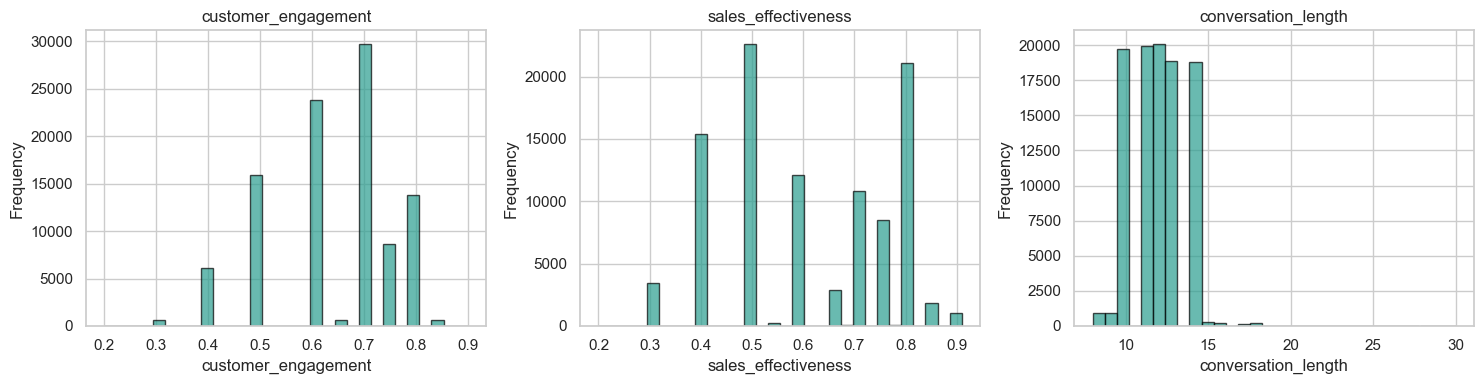

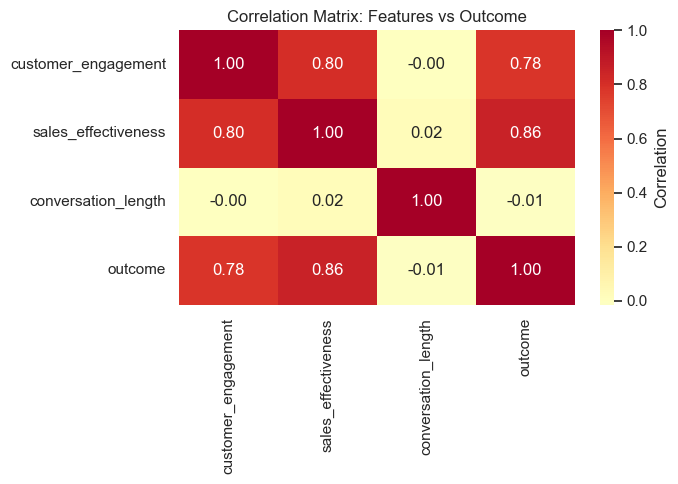

### Key Insights: Correlations with Outcome
- **Strongest predictor:** sales_effectiveness (r=0.856)
- **Features sorted by correlation strength**: sales_effectiveness (0.86), customer_engagement (0.78), conversation_length (-0.01)

/var/folders/78/ygj93tqd63s28fts9xbv6x_40000gn/T/ipykernel_68520/2387321994.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x="outcome_label", y=col, ax=ax, palette=["#e76f51", "#2a9d8f"])
/var/folders/78/ygj93tqd63s28fts9xbv6x_40000gn/T/ipykernel_68520/2387321994.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x="outcome_label", y=col, ax=ax, palette=["#e76f51", "#2a9d8f"])
/var/folders/78/ygj93tqd63s28fts9xbv6x_40000gn/T/ipykernel_68520/2387321994.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data

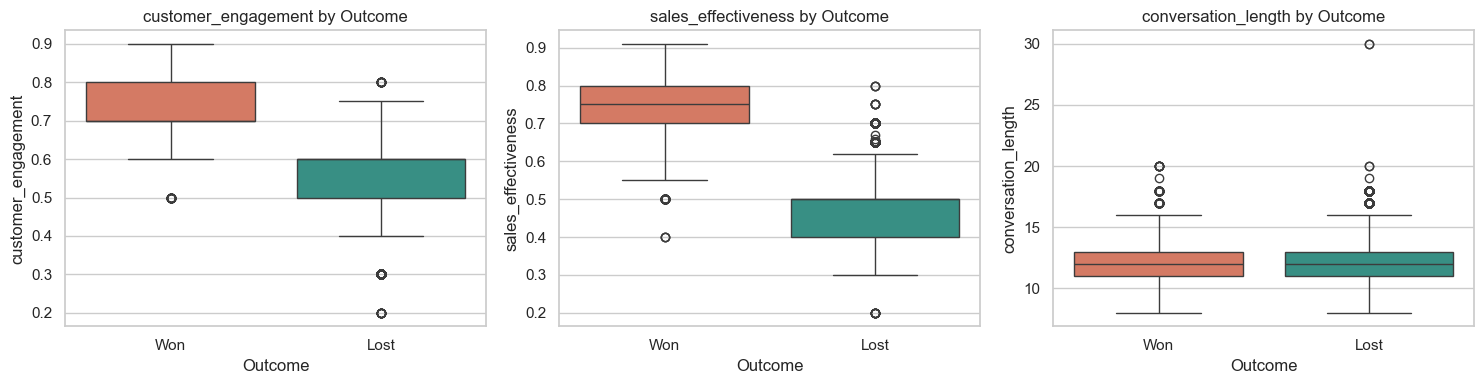

### Observation: Won vs Lost Conversations
- Boxplots show distribution differences between winning and losing conversations for each feature.

In [7]:
# 1) Simple numerical feature analysis: distributions, correlations, and class comparison

# Simple histograms for each numeric feature
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
if len(numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    ax.hist(eda_df[col], bins=30, color="#2a9d8f", alpha=0.7, edgecolor='black')
    ax.set_title(f"{col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Correlation heatmap
corr_matrix = eda_df[numeric_cols + ["outcome"]].corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, cbar_kws={"label": "Correlation"})
plt.title("Correlation Matrix: Features vs Outcome")
plt.tight_layout()
plt.show()

corr_with_target = corr_matrix["outcome"].drop("outcome").sort_values(ascending=False)
display(Markdown(
    "### Key Insights: Correlations with Outcome\n"
    f"- **Strongest predictor:** {corr_with_target.index[0]} (r={corr_with_target.iloc[0]:.3f})\n"
    f"- **Features sorted by correlation strength**: {', '.join([f'{col} ({val:.2f})' for col, val in corr_with_target.items()])}"
))

# Feature comparison by outcome (boxplots)
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
if len(numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=eda_df, x="outcome_label", y=col, ax=ax, palette=["#e76f51", "#2a9d8f"])
    ax.set_title(f"{col} by Outcome")
    ax.set_xlabel("Outcome")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

display(Markdown("### Observation: Won vs Lost Conversations\n- Boxplots show distribution differences between winning and losing conversations for each feature."))

### Analytical Commentary: Numerical Plots

The numerical panels jointly indicate that outcome separation is driven mostly by engagement and effectiveness, not by conversation length. This suggests a process-level interpretation: successful conversations are characterized by **quality intensity**, not merely interaction duration.

**Implication for preprocessing:** prioritize preserving the scale fidelity of engagement/effectiveness, and engineer normalized intensity features (for example, per-length ratios) so length acts as contextual denominator rather than a dominant predictor.

/var/folders/78/ygj93tqd63s28fts9xbv6x_40000gn/T/ipykernel_68520/1529618152.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_len.index, y=avg_len.values, palette=["#e76f51", "#2a9d8f"])


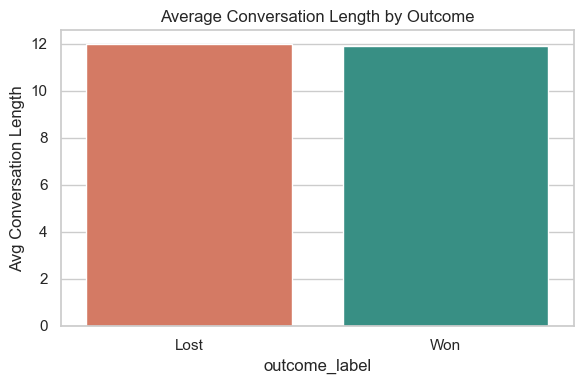

### Text Length Analysis
- **Won conversations:** avg 11.9 words
- **Lost conversations:** avg 12.0 words

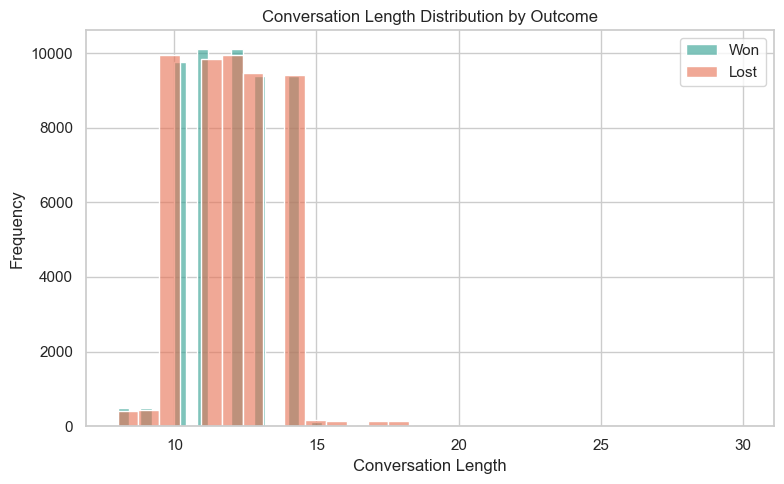

In [8]:
# 2) Simple text analysis: conversation length and basic statistics

# Conversation length by outcome
avg_len = eda_df.groupby("outcome_label")["conversation_length"].mean()
plt.figure(figsize=(6, 4))
sns.barplot(x=avg_len.index, y=avg_len.values, palette=["#e76f51", "#2a9d8f"])
plt.title("Average Conversation Length by Outcome")
plt.ylabel("Avg Conversation Length")
plt.tight_layout()
plt.show()

display(Markdown(
    f"### Text Length Analysis\n"
    f"- **Won conversations:** avg {avg_len.get('Won', 0):.1f} words\n"
    f"- **Lost conversations:** avg {avg_len.get('Lost', 0):.1f} words"
))

# Text length distribution by outcome
plt.figure(figsize=(8, 5))
sns.histplot(data=eda_df[eda_df["outcome_label"] == "Won"], x="conversation_length", bins=30, label="Won", color="#2a9d8f", alpha=0.6)
sns.histplot(data=eda_df[eda_df["outcome_label"] == "Lost"], x="conversation_length", bins=30, label="Lost", color="#e76f51", alpha=0.6)
plt.title("Conversation Length Distribution by Outcome")
plt.xlabel("Conversation Length")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Analytical Commentary: Text Analysis

Class-specific vocabulary and word frequency differences can guide domain-specific feature engineering. Surface vocabulary patterns, combined with structured features, provide richer signals for predicting sales outcomes.

**Implication for preprocessing:** represent text with semantic encoders (TF-IDF n-grams or embeddings) and combine them with structured features rather than relying on keyword frequency in isolation.

/var/folders/78/ygj93tqd63s28fts9xbv6x_40000gn/T/ipykernel_68520/3435942185.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Lost", "Won"], y=[class_counts.get(0, 0), class_counts.get(1, 0)], palette=["#e76f51", "#2a9d8f"])


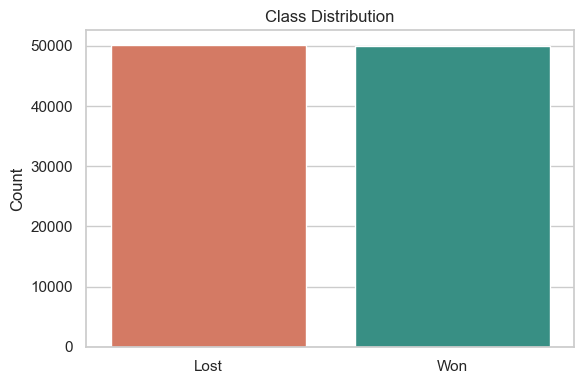

### Class Balance
- **Won (positive):** 49929 (49.9%)
- **Lost (negative):** 50071 (50.1%)

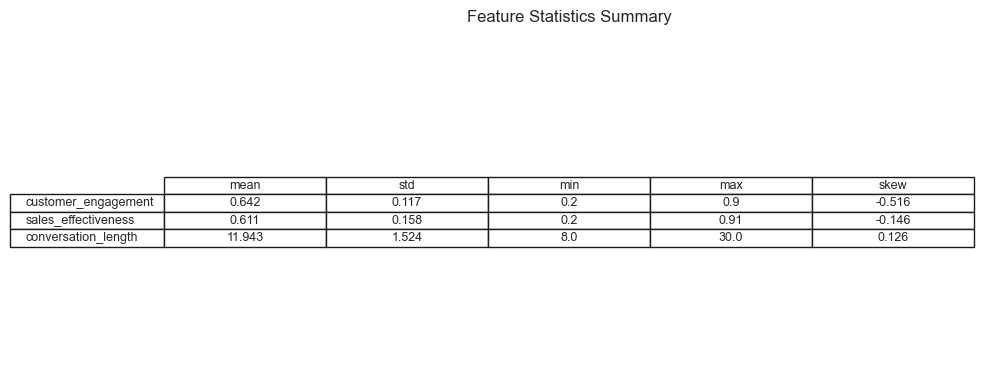

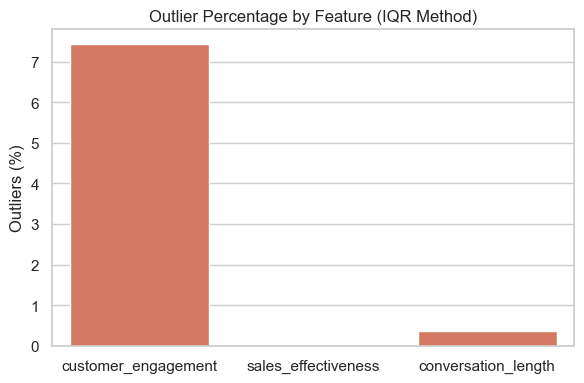

### Data Quality Summary
- See statistics table for distribution properties (mean, std, skewness)
- Outliers detected using IQR method (values beyond 1.5×IQR)

In [9]:
# 3) Data Quality: Class imbalance, skewness, and outliers

# Class distribution
class_counts = eda_df["outcome"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
sns.barplot(x=["Lost", "Won"], y=[class_counts.get(0, 0), class_counts.get(1, 0)], palette=["#e76f51", "#2a9d8f"])
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

total = len(eda_df)
display(Markdown(
    f"### Class Balance\n"
    f"- **Won (positive):** {class_counts.get(1, 0)} ({class_counts.get(1, 0)/total*100:.1f}%)\n"
    f"- **Lost (negative):** {class_counts.get(0, 0)} ({class_counts.get(0, 0)/total*100:.1f}%)"
))

# Feature statistics table
stats_df = eda_df[numeric_cols].describe().T
stats_df['skew'] = eda_df[numeric_cols].skew()
stats_df = stats_df[['mean', 'std', 'min', 'max', 'skew']]
plt.figure(figsize=(10, 4))
plt.axis('tight')
plt.axis('off')
table = plt.table(cellText=stats_df.round(3).values, colLabels=stats_df.columns, rowLabels=stats_df.index, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
plt.title("Feature Statistics Summary", pad=20)
plt.tight_layout()
plt.show()

# Outlier detection
outlier_pct_list = []
for col in numeric_cols:
    q1 = eda_df[col].quantile(0.25)
    q3 = eda_df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((eda_df[col] < q1 - 1.5*iqr) | (eda_df[col] > q3 + 1.5*iqr)).sum()
    outlier_pct_list.append(outliers / len(eda_df) * 100)

plt.figure(figsize=(6, 4))
sns.barplot(x=numeric_cols, y=outlier_pct_list, color="#e76f51")
plt.title("Outlier Percentage by Feature (IQR Method)")
plt.ylabel("Outliers (%)")
plt.tight_layout()
plt.show()

display(Markdown("### Data Quality Summary\n- See statistics table for distribution properties (mean, std, skewness)\n- Outliers detected using IQR method (values beyond 1.5×IQR)"))

### Analytical Commentary: Data Quality and Risk Plots

Near-balanced classes reduce immediate risk of majority-class bias, while low global skewness suggests no urgent need for aggressive monotonic transformations. However, concentrated outliers in engagement point to feature-specific instability.

**Implication for preprocessing:** use targeted robustness strategies (winsorization/outlier flags for engagement), maintain stratified splitting, and avoid blanket transformations that may remove informative business extremes.

The following synthesis consolidates the quantitative and qualitative evidence obtained from the EDA stage.
It translates empirical observations into a structured interpretation of predictive signal, data quality, and robustness considerations.
These insights are intended to guide the design of feature engineering and model development in subsequent phases.

## Key EDA Insights and Modeling Implications

### 1. Engagement and Sales Effectiveness as Dominant Predictive Signals
The EDA shows that sales_effectiveness and customer_engagement are the strongest observed predictors of conversion outcome. In particular:

- sales_effectiveness has a strong positive correlation with outcome (r approximately 0.86)
- customer_engagement also has a strong positive correlation with outcome (r approximately 0.78)

This pattern indicates that conversion is primarily associated with interaction quality rather than simple activity volume. In statistical terms, these variables exhibit high signal strength and a favorable signal-to-noise profile relative to other available predictors.

#### Modeling and preprocessing implications
- Preserve these high-signal variables with minimal distortion to avoid reducing predictive information.
- Prioritize interaction-based feature construction (for example, engagement × effectiveness) to capture joint effects not represented by additive terms alone.
- Under regularized models, track coefficient stability to ensure strong predictors improve generalization rather than inducing dominance-related variance.

---

### 2. Limited Standalone Utility of Conversation Length
conversation_length provides weak isolated predictive value:

- class-wise means are nearly identical (Won approximately 11.92, Lost approximately 11.97)
- correlation with outcome is near zero

Therefore, longer conversations are not intrinsically associated with higher conversion. Conceptually, this feature has low marginal information gain in standalone form, meaning it contributes little to discrimination unless contextualized.

#### Modeling and preprocessing implications
- Retain conversation_length as a contextual covariate, not a primary driver.
- Transform it into efficiency-style features (for example, engagement per unit length, effectiveness per unit length) to recover latent signal.
- In model interpretation, avoid over-attributing explanatory power to conversation duration alone.

---

### 3. Data Quality Profile: Balanced Outcome Distribution with Localized Robustness Requirements
The dataset appears suitable for baseline supervised classification:

- class balance is near-even (approximately 49.93% vs 50.07%)
- global skewness across key numeric variables is low

These properties reduce the immediate need for aggressive class-balancing interventions and support stable baseline fitting. However, customer_engagement contains a concentrated outlier share (approximately 7.4%), which introduces potential model sensitivity to outliers.

#### Modeling and preprocessing implications
- Use stratified splitting to preserve outcome proportions and reduce sampling bias.
- Avoid unnecessary global rebalancing techniques, given the near-balanced target distribution.
- Apply feature-specific robust treatment for customer_engagement (for example, clipping, winsorization, or outlier indicators) to control variance while preserving distributional structure.

---

## Integrated EDA to Modeling Rationale
Taken together, the EDA supports a coherent pipeline: emphasize high-signal interaction-quality predictors, treat duration as contextual with engineered efficiency terms, and apply selective robustness for localized outliers. This is consistent with a bias–variance tradeoff perspective: retain informative structure to limit bias, while controlling outlier-driven instability to limit variance. The result is a theoretically grounded transition from EDA to feature engineering and model design without changing the empirical findings.

These conclusions form the analytical foundation for the next phase, where feature engineering and model selection are operationalized and validated.